In [30]:
import pandas as pd

## Load dataset

In [31]:
data = pd.read_csv("spam.csv")

## Check dataset

In [32]:
data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [33]:
data.shape

(5572, 5)

In [34]:
data.describe()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [36]:
data.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

## Remove unnecessary columns

In [37]:
data = data.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)

In [38]:
data.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Rename columns

In [39]:
data = data.rename(columns={'v1': 'label', 'v2': 'message'})

In [40]:
data.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Vectorization

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [42]:
vectorizer = TfidfVectorizer()
x = vectorizer.fit_transform(data['message']).toarray()
y = data['label'].values

## Split data

In [43]:
from sklearn.model_selection import train_test_split

In [44]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [45]:
data['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

## Handle imbalanced dataset

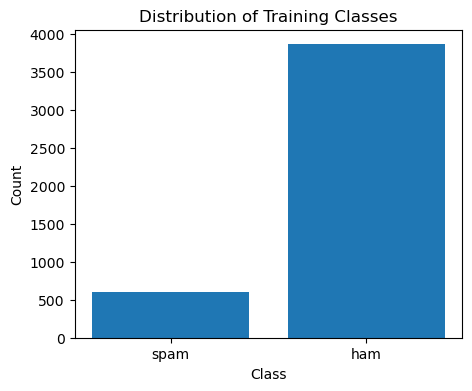

In [46]:
import matplotlib.pyplot as plt
import numpy as np

y_np = y_train.flatten()

y_num = np.where(y_np == 'spam', 0, 1)

counts = np.bincount(y_num)

labels = ['spam', 'ham']

plt.figure(figsize=(5,4))
plt.bar(labels, counts)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Distribution of Training Classes")
plt.show()

In [47]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
x_train, y_train = smote.fit_resample(x_train, y_train)

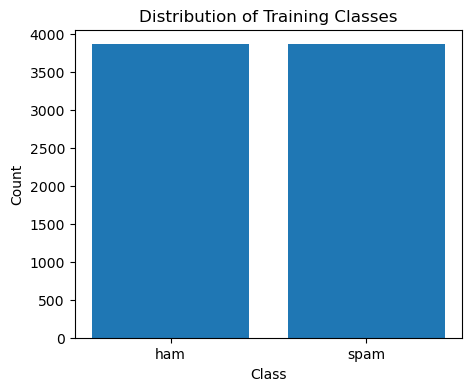

In [48]:
import matplotlib.pyplot as plt
import numpy as np

y_np = y_train.flatten()

labels, counts = np.unique(y_np, return_counts=True)

plt.figure(figsize=(5,4))
plt.bar(labels, counts)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Distribution of Training Classes")
plt.show()

In [49]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

## Convert to tensors

In [50]:
import torch
import torch.nn as nn

In [51]:
x_train = torch.tensor(x_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)

x_test = torch.tensor(x_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

## Build ANN model

In [52]:
class ANN(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.fc2 = nn.Linear(128, 64)
        self.out = nn.Linear(64, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.out(x))
        return x

model = ANN(x_train.shape[1])

## Train model

In [53]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 50

for epoch in range(epochs):
    outputs = model(x_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 5 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 0.6934897303581238
Epoch 5, Loss: 0.683231770992279
Epoch 10, Loss: 0.6612382531166077
Epoch 15, Loss: 0.6282214522361755
Epoch 20, Loss: 0.5820788145065308
Epoch 25, Loss: 0.519626259803772
Epoch 30, Loss: 0.4399253726005554
Epoch 35, Loss: 0.34648576378822327
Epoch 40, Loss: 0.2506871223449707
Epoch 45, Loss: 0.1667352169752121


## Check accuracy

In [54]:
model.eval()

with torch.no_grad():
    train_pred = model(x_train)
    train_class = (train_pred >= 0.5).float()

    train_acc = (train_class == y_train).float().mean()

print("Train Accuracy:", train_acc.item())

Train Accuracy: 0.999093234539032


In [55]:
model.eval()

with torch.no_grad():
    test_pred = model(x_test)
    test_class = (test_pred >= 0.5).float()

    test_acc = (test_class == y_test).float().mean()

print("Test Accuracy:", test_acc.item())

Test Accuracy: 0.9784753322601318


## Confusion matrix

In [56]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test.cpu(), test_class.cpu())

print(cm)

[[959   6]
 [ 18 132]]
